# Serving Your Portfolio Model with Flask

Flask is a lightweight synchronous web framework — battle-tested, simple, and widely deployed. In this notebook you will wrap **the model you exported from AIAT 114 or AIAT 122** in a Flask API and test it entirely inside the notebook using Flask's built-in test client (no live server needed).

## 🔗 Where this fits

**Builds on:** AIAT 115 (Course 05) — Unit 5, `08_deployment.ipynb` — where you pickled a model, wrote a `model_metadata.json` beside it, and served it from Flask and FastAPI. Course 11 makes that pairing formal: every artifact travels with a `model_card.json`, and the serving code reads the card instead of hard-coding what the model expects.

**Needs:** a portfolio model — see [`../../PORTFOLIO_MODEL.md`](../../PORTFOLIO_MODEL.md). Without one, this notebook serves the named fallback `wdbc-baseline` and says so in its output.


## 📰 Air Canada had to pay for what its endpoint said

Jake Moffatt asked Air Canada's website chatbot about bereavement fares after his grandmother died. The chatbot told him he could book now and apply for the reduced fare within 90 days. The airline's actual policy said the opposite, on a page the chatbot itself linked to. Air Canada argued it should not be liable for what the bot said. On **14 February 2024** the British Columbia Civil Resolution Tribunal disagreed (*Moffatt v. Air Canada*, 2024 BCCRT 149), found negligent misrepresentation, and awarded **CAD 812.02**. The tribunal's reasoning is the part worth memorising: the company is responsible for all the information on its website, whether it comes from a static page or from a model.

The money is trivial. The principle is not. **Whatever your endpoint returns is a statement your organisation has made.** That is why the difference between "returned a wrong answer with `200 OK`" and "refused with `400`" is not a stylistic choice.

**What goes wrong without this lesson.** Flask hands you nothing for free: no validation, no schema, no status-code discipline. Write the handler without thinking and you get a service that returns `200` with a garbage prediction when a field is missing, or `500` when the *caller* sent bad JSON — blaming your server for the client's mistake. Callers then build retry logic, dashboards and business decisions on top of a service whose replies do not mean what they appear to mean.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain when to choose Flask vs FastAPI for model serving
2. Build a Flask app that serves your own artifact via `/predict` and `/health`
3. Write input validation by hand and return correct HTTP status codes (400 / 500)
4. Test a Flask app in-notebook using `app.test_client()`
5. Verify a serving layer against the **golden batch** recorded in the model card
6. Describe how to run Flask with Gunicorn in production

## 1. Flask vs FastAPI — Quick Comparison

| | Flask | FastAPI |
|---|---|---|
| Style | Synchronous (WSGI) | Async-first (ASGI) |
| Docs | Manual | Auto OpenAPI / Swagger |
| Validation | Manual | Pydantic (automatic) |
| Maturity | ~15 years, massive ecosystem | ~5 years, fast-growing |
| Best for | Simple APIs, legacy codebases | High-throughput, data validation |

Choose Flask when your team already uses it or when you need a simpler mental model. FastAPI is covered in the next notebook.

## 2. Load the Portfolio Model

No training happens in this lesson — the model arrived finished. We load the artifact plus the card that says what it expects — feature order, class names, a real sample row, and a golden batch we will use in section 5.

In [1]:
# WHAT: load YOUR portfolio model and its card - no training happens here.
# WHY: the Flask app must load a FINISHED artifact from disk. Training offline and
# serving from an artifact is the separation every real deployment relies on, and
# in this course the offline training already happened, in AIAT 114 or AIAT 122.
import json
import sys
from pathlib import Path

for _d in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (_d / "portfolio_model.py").exists():
        COURSE11 = _d
        break
else:
    raise FileNotFoundError("Could not find portfolio_model.py - run this notebook from inside Course 11.")

if str(COURSE11) not in sys.path:
    sys.path.insert(0, str(COURSE11))

import portfolio_model as pf

# Builds the named fallback 'wdbc-baseline' if you have not exported a model yet.
model, card = pf.load_portfolio_model()
MODEL_DIR = pf.portfolio_dir()

# The API field names Flask will require, derived from the card's feature order.
FIELDS = pf.schema_fields(card)
FIELD_ORDER = [field for field, _ in FIELDS]
print(f"\nAPI will require {len(FIELD_ORDER)} fields, e.g. {FIELD_ORDER[:3]}")


FALLBACK MODEL 'wdbc-baseline' — this is NOT your model.
  directory   : /Users/abdullah/ai-diploma-portfolio
  artifact    : model.joblib  (sklearn)
  task        : classification  ->  2 classes ['malignant', 'benign']
  features    : 30 (first three: ['mean radius', 'mean texture', 'mean perimeter'])
  accuracy    : 0.9825 on held-out 20% (random_state=42, stratified)
  Export your own model from AIAT 114 or AIAT 122 and re-run: see Course 11/PORTFOLIO_MODEL.md

API will require 30 fields, e.g. ['mean_radius', 'mean_texture', 'mean_perimeter']


## 3. Write the Flask Application

`%%writefile` saves the cell content to a file. The key design decisions:
- Load the artifact and card **once** at startup (not inside the predict function)
- Derive the required fields from `card["feature_names"]` — never type them by hand
- Return **400** for bad input (client's fault), **500** for unexpected errors (server's fault)
- Keep the route handlers thin — delegate logic to helper functions

Watch how much code `validate_input` takes. Flask gives you nothing for free here; the next notebook deletes this entire function and replaces it with a type hint.

In [2]:
%%writefile /tmp/flask_app.py
# WHAT: write the complete Flask serving app to /tmp/flask_app.py.
# WHY: this file is the deployable unit - note the three responsibilities it
# separates: startup loading, input validation, and error-coded responses.
# Flask has no Pydantic, so every check below is one we write by hand. Keep that
# in mind when the next notebook does the same job with a type hint.
import json
import os
import re
from pathlib import Path

import numpy as np
from flask import Flask, request, jsonify

app = Flask(__name__)

# --- Load the artifact and its card once, at startup ---
MODEL_DIR = Path(os.environ.get("AI_DIPLOMA_PORTFOLIO",
                                str(Path.home() / "ai-diploma-portfolio")))
CARD = json.loads((MODEL_DIR / "model_card.json").read_text())

if CARD["framework"] == "sklearn":
    import joblib
    _model = joblib.load(MODEL_DIR / CARD["artifact"])

    def probabilities(rows):
        return np.asarray(_model.predict_proba(rows))

elif CARD["framework"] == "onnx":
    import onnxruntime as ort
    _session = ort.InferenceSession(str(MODEL_DIR / CARD["artifact"]),
                                    providers=["CPUExecutionProvider"])
    _input = _session.get_inputs()[0].name

    def probabilities(rows):
        logits = np.asarray(_session.run(None, {_input: np.asarray(rows, dtype=np.float32)})[0])
        exp = np.exp(logits - logits.max(axis=1, keepdims=True))
        return exp / exp.sum(axis=1, keepdims=True)

else:
    raise RuntimeError(f"This app serves 'sklearn' or 'onnx' artifacts, not {CARD['framework']!r}.")


def api_field(name):
    slug = re.sub(r"\W+", "_", str(name).strip().lower()).strip("_")
    return f"f_{slug}" if not slug or slug[0].isdigit() else slug

# The required request fields ARE the model's features, in training order.
REQUIRED_FEATURES = [api_field(n) for n in CARD["feature_names"]]
CLASSES = CARD["class_names"]


# One function owns ALL input checking - the endpoint stays readable.
def validate_input(data):
    """Return (features_array, error_message). error_message is None if valid."""
    if not isinstance(data, dict):
        return None, "Request body must be a JSON object"
    missing = [f for f in REQUIRED_FEATURES if f not in data]
    if missing:
        return None, f"Missing fields: {missing[:5]}{'...' if len(missing) > 5 else ''}"
    try:
        features = np.array([[float(data[f]) for f in REQUIRED_FEATURES]])
    except (TypeError, ValueError) as e:
        return None, f"All fields must be numeric: {e}"
    return features, None


# Liveness endpoint: load balancers and Kubernetes probes call this.
@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok",
                    "model": CARD["name"],
                    "source": CARD["source_course"],
                    "n_features": len(REQUIRED_FEATURES)}), 200


# The prediction endpoint: validate first, predict second, report errors honestly.
@app.route("/predict", methods=["POST"])
def predict():
    features, error = validate_input(request.get_json(silent=True))
    if error:
        # 400 = the CLIENT sent something wrong. Say exactly what.
        return jsonify({"error": error}), 400
    try:
        proba = probabilities(features)[0]
        class_id = int(np.argmax(proba))
        return jsonify({
            "prediction": CLASSES[class_id],
            "class_id": class_id,
            "confidence": round(float(proba[class_id]), 4),
        }), 200
    except Exception as e:  # noqa: BLE001 - a serving app must never leak a stack trace
        # 500 = OUR fault. Log the detail, return something safe.
        app.logger.exception("prediction failed")
        return jsonify({"error": "internal error", "detail": str(e)}), 500


Overwriting /tmp/flask_app.py


## 4. Test with Flask's Test Client

`app.test_client()` lets you send HTTP requests to your Flask app without starting a real server. This is how you write tests and also how we experiment in-notebook.

In [3]:
# WHAT: exercise the app through Flask's in-process test client - health check,
# a valid request built from the card, then two malformed requests.
# WHY: each test pins down one guarantee of the API contract; the expected status
# codes (200 vs 400) matter as much as the prediction itself.
import importlib
import sys

sys.path.insert(0, "/tmp")
import flask_app as flask_module
importlib.reload(flask_module)
client = flask_module.app.test_client()

# --- Test 1: Health check ---
resp = client.get("/health")
print("Health check :", resp.status_code, resp.get_json())

# --- Test 2: Valid prediction, from the card's real sample row ---
payload = dict(zip(FIELD_ORDER, card["sample_input"]))
resp = client.post("/predict", json=payload)
print("Valid request:", resp.status_code, resp.get_json())

# --- Test 3: Missing fields (expect 400) ---
resp = client.post("/predict", json={FIELD_ORDER[0]: payload[FIELD_ORDER[0]]})
print("Missing      :", resp.status_code, resp.get_json())

# --- Test 4: Non-numeric value (expect 400) ---
resp = client.post("/predict", json={**payload, FIELD_ORDER[0]: "big"})
print("Non-numeric  :", resp.status_code, resp.get_json())


Health check : 200 {'model': 'wdbc-baseline', 'n_features': 30, 'source': 'AIAT 125 fallback', 'status': 'ok'}
Valid request: 200 {'class_id': 1, 'confidence': 0.9991, 'prediction': 'benign'}
Missing      : 400 {'error': "Missing fields: ['mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness']..."}
Non-numeric  : 400 {'error': "All fields must be numeric: could not convert string to float: 'big'"}


## 5. Golden-Batch Verification

The card carries `sample_batch` — up to 20 real held-out rows — together with `sample_batch_predictions`, the class the model produced for each of those rows **at export time**.

That pairing is a regression test for the *serving stack*. Push the golden rows through the API and every answer must still match. If one does not, the model file has not changed — so the fault is in your serving code: a scrambled feature order, a lost scaler, a float parsed as a string. This is the single cheapest check that stands between you and a silent production bug.

In [4]:
# WHAT: replay the card's golden batch through the HTTP API and compare each
# answer with the prediction recorded when the model was exported.
# WHY: serving adds JSON parsing, float conversion and a network hop. This is the
# check that proves none of it changed the model's mind. If a row disagrees, the
# serving stack is at fault - the model on disk has not changed since export.
golden_rows = card["sample_batch"]
expected = card["sample_batch_predictions"]

api_predictions = []
for row in golden_rows:
    resp = client.post("/predict", json=dict(zip(FIELD_ORDER, row)))
    api_predictions.append(resp.get_json()["class_id"])

matches = sum(a == e for a, e in zip(api_predictions, expected))
print(f"Golden batch: {matches}/{len(expected)} API answers match the export-time predictions")

for i in range(3):
    print(f"  row {i}: api={card['class_names'][api_predictions[i]]:<12} "
          f"recorded at export={card['class_names'][expected[i]]}")

if matches != len(expected):
    raise AssertionError("The serving layer changed a prediction - do not deploy this.")
print("\nServing layer verified: HTTP in, identical model behaviour out.")


Golden batch: 20/20 API answers match the export-time predictions
  row 0: api=malignant    recorded at export=malignant
  row 1: api=benign       recorded at export=benign
  row 2: api=malignant    recorded at export=malignant

Serving layer verified: HTTP in, identical model behaviour out.


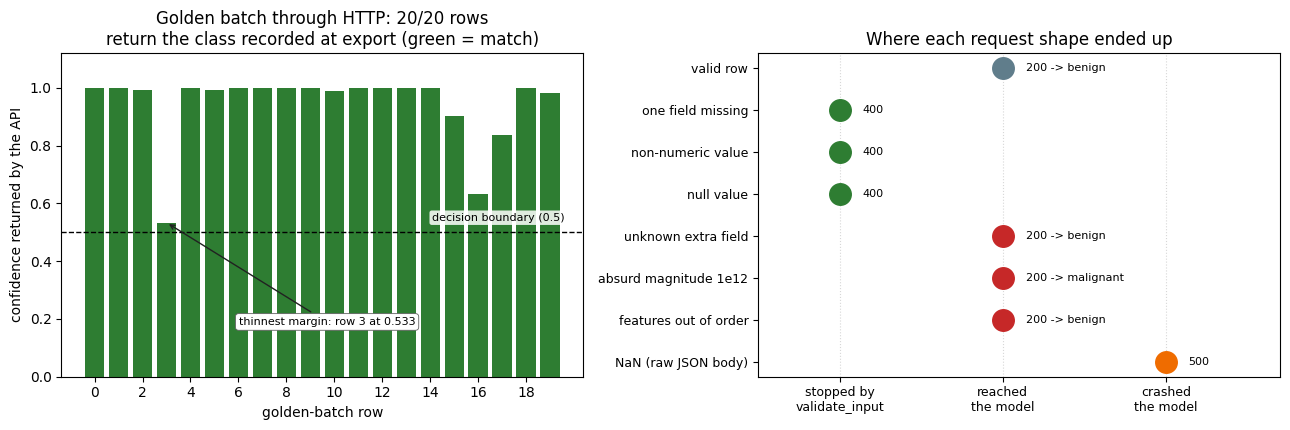

Golden batch : 20/20 rows match; confidence range 0.533 - 1.000
request shape            status   outcome
valid row                200      answered 'benign'
one field missing        400      rejected
non-numeric value        400      rejected
null value               400      rejected
unknown extra field      200      answered 'benign'
absurd magnitude 1e12    200      answered 'malignant'
features out of order    200      answered 'benign'
NaN (raw JSON body)      500      server error


In [5]:
# WHAT: draw the two things this notebook just proved - left, the golden batch's
# confidence per row with agreement colour-coded; right, where each shape of
# request actually ended up (stopped by validate_input / reached the model / crashed it).
# WHY: "20/20 match" and "hand-written validation only catches what you thought of"
# are the lesson's two claims. Both are measured here, through the same test client.
import logging

import matplotlib.pyplot as plt

# --- Left panel: replay the golden rows, this time keeping the confidence too ---
gold_conf, gold_pred = [], []
for row in golden_rows:
    body = client.post("/predict", json=dict(zip(FIELD_ORDER, row))).get_json()
    gold_conf.append(body["confidence"])
    gold_pred.append(body["class_id"])
agrees = [p == e for p, e in zip(gold_pred, expected)]

# --- Right panel: one request per malformed shape, recording only the status code ---
valid_payload = dict(zip(FIELD_ORDER, card["sample_input"]))
values = list(card["sample_input"])
battery = [
    ("valid row",             valid_payload),
    ("one field missing",     dict(list(valid_payload.items())[:-1])),
    ("non-numeric value",     {**valid_payload, FIELD_ORDER[0]: "big"}),
    ("null value",            {**valid_payload, FIELD_ORDER[0]: None}),
    ("unknown extra field",   {**valid_payload, "surprise": 1.0}),
    ("absurd magnitude 1e12", {**valid_payload, FIELD_ORDER[0]: 1e12}),
    ("features out of order", dict(zip(FIELD_ORDER, values[1:] + values[:1]))),
    ("NaN (raw JSON body)",   None),   # sent as a raw body: json.dumps writes a NaN token
]

# The NaN request reaches the model and raises; Flask logs that traceback. We are
# expecting it, so quieten the logger and read the status code instead.
flask_module.app.logger.setLevel(logging.CRITICAL)

statuses, answers = [], []
for name, body in battery:
    if body is None:
        raw = json.dumps({**valid_payload, FIELD_ORDER[0]: float("nan")})
        resp = client.post("/predict", data=raw, content_type="application/json")
    else:
        resp = client.post("/predict", json=body)
    statuses.append(resp.status_code)
    payload_out = resp.get_json() or {}
    answers.append(payload_out.get("prediction"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.bar(range(len(gold_conf)),
       gold_conf,
       color=["#2e7d32" if a else "#c62828" for a in agrees])
ax.axhline(0.5, ls="--", lw=1, color="black")
ax.text(len(gold_conf) - 0.4, 0.54, "decision boundary (0.5)", fontsize=8, ha="right",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
thinnest = min(range(len(gold_conf)), key=lambda i: gold_conf[i])
ax.annotate(f"thinnest margin: row {thinnest} at {gold_conf[thinnest]:.3f}",
            xy=(thinnest, gold_conf[thinnest]), xytext=(0.34, 0.16),
            textcoords="axes fraction", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#616161", lw=0.6),
            arrowprops=dict(arrowstyle="->", lw=1, color="#212121"))
ax.set_xticks(range(0, len(gold_conf), 2))
ax.set_ylim(0, 1.12)
ax.set_xlabel("golden-batch row")
ax.set_ylabel("confidence returned by the API")
ax.set_title(f"Golden batch through HTTP: {sum(agrees)}/{len(agrees)} rows\n"
             f"return the class recorded at export (green = match)")

ax = axes[1]
LANE = {4: 0, 2: 1, 5: 2}
for y, ((name, _), code, pred) in enumerate(zip(battery, statuses, answers)):
    family = code // 100
    x = LANE[family]
    if family == 4:
        colour = "#2e7d32"                      # stopped: the validator did its job
    elif family == 5:
        colour = "#ef6c00"                      # reached the model and broke it
    else:
        colour = "#607d8b" if name == "valid row" else "#c62828"
    ax.scatter([x], [y], s=240, color=colour, zorder=3)
    label = f"{code}" + (f" -> {pred}" if pred else "")
    ax.text(x + 0.14, y, label, va="center", fontsize=8)
ax.set_yticks(range(len(battery)))
ax.set_yticklabels([n for n, _ in battery], fontsize=9)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["stopped by\nvalidate_input", "reached\nthe model", "crashed\nthe model"],
                   fontsize=9)
ax.set_xlim(-0.5, 2.7)
ax.invert_yaxis()
ax.grid(axis="x", ls=":", alpha=0.5)
ax.set_title("Where each request shape ended up")

plt.tight_layout()
plt.show()

# The same two panels as text, so the claim can be checked without the picture.
print(f"Golden batch : {sum(agrees)}/{len(agrees)} rows match; "
      f"confidence range {min(gold_conf):.3f} - {max(gold_conf):.3f}")
print(f"{'request shape':<24} {'status':<8} outcome")
for (name, _), code, pred in zip(battery, statuses, answers):
    outcome = {4: "rejected", 2: f"answered '{pred}'", 5: "server error"}[code // 100]
    print(f"{name:<24} {code:<8} {outcome}")


**Reading the figure.** *Left:* every one of the 20 golden rows comes back green — the
HTTP layer returned exactly the class recorded when the model was exported, and the bar
heights show how much room each row had. The shortest bar is the row closest to the 0.5
boundary; a serving bug that nudges a feature would flip that row first, which is why the
margin, not just the match, is worth looking at.

*Right:* eight request shapes, one dot each, placed in the lane where the request actually
ended. Three are caught by `validate_input` and never reach the model (green, `400`); the grey dot
is the legitimate row, answered correctly. The three red dots are the point of the lesson: an **unknown extra
field**, an **absurd magnitude**, and **features supplied in the wrong order** are all accepted
with `200` and a confident answer, because the hand-written validator checks presence and
numeric type and nothing else. The amber dot is `NaN`, which passes validation, reaches
scikit-learn, and turns into a `500`. This is the "⚠️ Where this breaks" section, measured.

## 💬 Discuss

The golden batch just printed **20/20 API answers match the export-time predictions**. That is a strong result and a narrow one — argue about its edges.

1. The golden batch rules out a whole family of serving bugs. Name precisely which family, then name a serving bug it would *not* catch. (Hint: what would happen if every client sent features in a consistently wrong order?)
2. Our app returns `400` for a missing field and `500` for an unexpected error. After the Air Canada ruling, which is worse for the business: a `400` that a client's dashboard shows as an outage, or a `200` carrying a prediction built from a defaulted field? Argue it from the client's side too — they may prefer the number.
3. `sample_batch` holds up to 20 rows chosen at export time. If you could choose which 20 rows travel with the artifact forever, what would you pick, and why is "the first 20 test rows" probably the wrong answer?

## 6. Production Deployment with Gunicorn

Flask's built-in development server is single-threaded and not safe for production. Gunicorn is a production-grade WSGI server that spawns multiple worker processes.

```bash
# Install
pip install gunicorn

# Run with 4 worker processes (rule of thumb: 2 * CPU cores + 1)
gunicorn flask_app:app --workers 4 --bind 0.0.0.0:5000
```

The request body has one field per feature in *your* card, so build the `curl` from the card rather than copying one from a tutorial — Unit 1's notebook 01 prints a ready-made one for your model.

**Gunicorn vs dev server:**
- Dev server: 1 thread, restarts on code change, never use in production
- Gunicorn: multiple workers, stable, handles concurrent requests

**One caution for ML:** each Gunicorn worker is a separate process that loads its own copy of the artifact. Four workers means four copies of the model in RAM — fine for a 2 KB logistic regression, a real capacity decision for a 500 MB network.

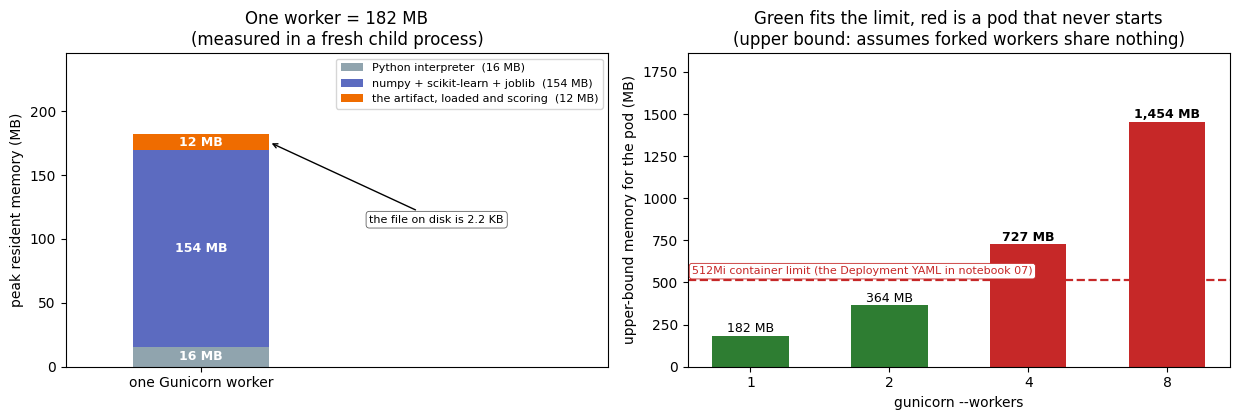

artifact on disk                 :      2.2 KB
bare Python interpreter          :       16 MB
+ numpy / scikit-learn / joblib  :      154 MB
+ artifact loaded and scoring    :       12 MB
= one worker                     :      182 MB

--workers     upper-bound total   fits in 512 MB?
1                        182 MB   yes
2                        364 MB   yes
4                        727 MB   NO
8                      1,454 MB   NO

The artifact is 5,511x bigger in RAM than on disk, and it is still the smallest
of the three parts: 85% of a worker is imports this model never chose.
--workers 4 is the first setting that cannot start in a 512 MB container.


In [6]:
# WHAT: measure what ONE serving process really costs in memory - a fresh
# interpreter, then the ML imports, then the loaded artifact - and multiply that
# by the worker counts section 6 recommends, against a real container limit.
# WHY: "--workers 4 means four copies of the model in RAM" is the sizing rule this
# section states. It is only half the story, and the half that is missing is the
# half that kills pods. We measure it instead of asserting it.
import subprocess
import sys

import matplotlib.pyplot as plt

# A short-lived child process is the honest way to measure a worker: it starts
# from nothing, exactly as a freshly forked Gunicorn worker does. ru_maxrss is
# the PEAK resident memory, so the three readings only ever grow.
PROBE = r"""
import json, os, resource, sys
from pathlib import Path

def rss_mb():
    r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return r / (1024 * 1024) if sys.platform == "darwin" else r / 1024   # macOS reports bytes, Linux KB

base = rss_mb()                                     # (1) bare interpreter
MODEL_DIR = Path(os.environ.get("AI_DIPLOMA_PORTFOLIO",
                                str(Path.home() / "ai-diploma-portfolio")))
card = json.loads((MODEL_DIR / "model_card.json").read_text())
import numpy, joblib, sklearn                        # noqa: F401 - imported for their memory cost
imports = rss_mb()                                  # (2) after the serving stack's imports
model = joblib.load(MODEL_DIR / card["artifact"])
model.predict_proba([card["sample_input"]])          # score one row: allocates what serving allocates
loaded = rss_mb()                                   # (3) after the artifact is live
print(json.dumps({"base": base, "imports": imports, "loaded": loaded,
                  "artifact_kb": (MODEL_DIR / card["artifact"]).stat().st_size / 1024}))
"""

proc = subprocess.run([sys.executable, "-c", PROBE], capture_output=True, text=True, timeout=180)
m = json.loads(proc.stdout.strip().splitlines()[-1])

interp_mb = m["base"]                      # cost of Python itself
libs_mb = m["imports"] - m["base"]         # cost of numpy + scikit-learn + joblib
model_mb = m["loaded"] - m["imports"]      # cost of the artifact once loaded and used
worker_mb = m["loaded"]                    # what one whole worker holds
artifact_kb = m["artifact_kb"]

WORKERS = [1, 2, 4, 8]                     # section 6's rule of thumb, 2 * cores + 1, lands in here
LIMIT_MB = 512                             # memory limit in Unit 4 / notebook 07's Deployment YAML

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

# --- Left: where one worker's memory actually goes ---------------------------
ax = axes[0]
parts = [("Python interpreter", interp_mb, "#90a4ae"),
         ("numpy + scikit-learn + joblib", libs_mb, "#5c6bc0"),
         ("the artifact, loaded and scoring", model_mb, "#ef6c00")]
bottom = 0.0
for label, height, colour in parts:
    ax.bar([0], [height], bottom=bottom, width=0.5, color=colour, label=f"{label}  ({height:,.0f} MB)")
    ax.text(0, bottom + height / 2, f"{height:,.0f} MB", ha="center", va="center",
            color="white", fontsize=9, fontweight="bold")
    bottom += height
ax.annotate(f"the file on disk is {artifact_kb:.1f} KB",
            xy=(0.25, worker_mb - model_mb / 2), xytext=(0.62, worker_mb * 0.62),
            fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#616161", lw=0.6),
            arrowprops=dict(arrowstyle="->", lw=1))
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0])
ax.set_xticklabels(["one Gunicorn worker"])
ax.set_ylim(0, worker_mb * 1.35)
ax.set_ylabel("peak resident memory (MB)")
ax.set_title(f"One worker = {worker_mb:,.0f} MB\n(measured in a fresh child process)")
ax.legend(fontsize=8, loc="upper right")

# --- Right: multiply that by the worker count, against a real container limit -
ax = axes[1]
totals = [worker_mb * w for w in WORKERS]
colours = ["#c62828" if t > LIMIT_MB else "#2e7d32" for t in totals]
ax.bar([str(w) for w in WORKERS], totals, color=colours, width=0.55)
for i, (w, t) in enumerate(zip(WORKERS, totals)):
    ax.text(i, t + worker_mb * 0.12, f"{t:,.0f} MB", ha="center", fontsize=9,
            fontweight="bold" if t > LIMIT_MB else "normal")
ax.axhline(LIMIT_MB, color="#c62828", ls="--", lw=1.6)
ax.text(-0.42, LIMIT_MB * 1.05,
        "512Mi container limit (the Deployment YAML in notebook 07)",
        fontsize=8, color="#c62828", ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#c62828", lw=0.6))
ax.set_ylim(0, max(max(totals), LIMIT_MB) * 1.28)
ax.set_xlabel("gunicorn --workers")
ax.set_ylabel("upper-bound memory for the pod (MB)")
ax.set_title("Green fits the limit, red is a pod that never starts\n"
             "(upper bound: assumes forked workers share nothing)")

plt.tight_layout()
plt.show()

# The same numbers as text, so the claim survives without the picture.
print(f"artifact on disk                 : {artifact_kb:>8.1f} KB")
print(f"bare Python interpreter          : {interp_mb:>8.0f} MB")
print(f"+ numpy / scikit-learn / joblib  : {libs_mb:>8.0f} MB")
print(f"+ artifact loaded and scoring    : {model_mb:>8.0f} MB")
print(f"= one worker                     : {worker_mb:>8.0f} MB\n")
print(f"{'--workers':<12} {'upper-bound total':>18}   fits in {LIMIT_MB} MB?")
for w, t in zip(WORKERS, totals):
    print(f"{w:<12} {t:>15,.0f} MB   {'yes' if t <= LIMIT_MB else 'NO'}")
first_over = next((w for w, t in zip(WORKERS, totals) if t > LIMIT_MB), None)
print(f"\nThe artifact is {model_mb * 1024 / artifact_kb:,.0f}x bigger in RAM than on disk, and it is "
      f"still the smallest\nof the three parts: {libs_mb / worker_mb:.0%} of a worker is imports this model never chose.")
if first_over:
    print(f"--workers {first_over} is the first setting that cannot start in a {LIMIT_MB} MB container.")


**Reading the memory figure.** *Left:* one serving worker, taken apart. The orange slice — the artifact
loaded and scoring a row — is the only part of the bar that is *your model*, and the annotation
gives its size on disk for comparison. The two slices underneath are Python and the scientific
stack, and together they are the overwhelming majority of the worker. **The thing that fills a
serving container is almost never the model file.** That is why "our model is only a few
kilobytes, memory is not a concern" is one of the most reliable ways to get a pod killed.

*Right:* the same measured worker, multiplied by the `--workers` values section 6 recommends,
against the `memory: 512Mi` limit written in the Deployment YAML two notebooks from now. Green
bars fit; red bars do not. Note what the red bars mean operationally: the container does not slow
down, it is killed by the kernel's OOM killer during startup, and Kubernetes reports a crash loop —
a symptom that looks nothing like "we asked for too many workers".

Two honesty notes. The bars are an **upper bound**: forked workers share unmodified pages
copy-on-write, so a real four-worker pod uses less than four times one worker, and `--preload`
increases that sharing further. And these are this machine's numbers for this artifact — a
500 MB network, the example in section 6, moves the orange slice from the smallest part of the
bar to the largest and changes the answer entirely. Measure your own before you pick a number.


## 7. Summary

In this notebook you:
- Loaded **your portfolio artifact and its card** — the deployment job starts where training ended
- Built a Flask app that reads its required fields from `card["feature_names"]`
- Wrote input validation by hand, returning **400** for bad client input and **500** for server errors
- Tested the entire API in-notebook using `app.test_client()` — no live server needed
- Replayed the card's **golden batch** and proved the HTTP layer did not change a single prediction
- Learned how to run Flask with Gunicorn for production traffic

The Flask serving pattern is: **load artifact + card once at startup → validate input → predict → return JSON with an honest status code**.

**Next:** the same artifact, the same endpoints, served by FastAPI — so you can compare the two frameworks with the model held constant.

## Self-Check (answer before scrolling up)

1. **What does `app.test_client()` give you?** (Hint: think about what you avoided by using it)
2. **What is the difference between Flask's dev server and Gunicorn?** Name at least two differences.
3. **Why return 400 for bad input instead of 500?** What does each status code communicate to the caller?
4. **The golden batch passed. What class of bug does that rule out, and what class does it *not* rule out?**
5. **Why does the app read `card["feature_names"]` instead of a hard-coded list of field names?**

## ⚠️ Where this breaks

- **Hand-written validation only catches what you thought of.** `validate_input` checks presence and numeric type. It does not check ranges, `NaN`, `Infinity`, absurd magnitudes, or field *ordering* — and every one of those reaches the model. The next notebook replaces the whole function with a type hint precisely because hand-written checks rot: a new feature is added, the validator is not updated, and the gap is silent.
- **Four Gunicorn workers means four copies of the model in RAM.** The lesson says this and it is worth repeating as a limit, not a footnote: a 500 MB artifact at `--workers 4` is 2 GB before a single request. On a container with a 1 GB memory limit, Kubernetes kills the pod on startup and the deployment fails in a way that looks like a crash loop rather than a sizing mistake (Unit 4, notebook 02).
- **Flask is synchronous, and that is a real ceiling.** One worker process handles one request at a time. If your handler waits on a feature store or another service, workers block on I/O and throughput collapses long before CPU does. That is the specific case FastAPI's async model is for — not a general "FastAPI is faster".
- **The assumption that must hold:** the golden batch was recorded by the same artifact you are serving. If someone re-exports the model but keeps the old card, the golden batch will fail — which is the point — but if someone re-exports *both*, the check passes trivially and proves nothing. A regression test is only as good as the baseline's independence.
- **The cheaper alternative.** If you already have a FastAPI codebase, do not add a Flask service for one model. The reason to choose Flask is an existing Flask ecosystem, a team that knows it, or a WSGI-only deployment target — not performance.

## 📚 References

1. Fielding, R. T. (2000). *Architectural Styles and the Design of Network-based Software Architectures* (Ch. 5: REST). PhD dissertation, University of California, Irvine.
2. Crankshaw, D., Wang, X., Zhou, G., Franklin, M. J., Gonzalez, J. E., & Stoica, I. (2017). *Clipper: A Low-Latency Online Prediction Serving System*. NSDI. <https://arxiv.org/abs/1612.03079>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Park, S., Jeon, S., Lee, C., Jeon, S., Kim, B.-S., & Lee, J. (2025). *A Survey on Inference Engines for Large Language Models: Perspectives on Optimization and Efficiency*. arXiv. <https://arxiv.org/abs/2505.01658> — compares 25 open-source and commercial serving engines on stated criteria (optimization support, scalability, ease of deployment). It is the evidence base for a decision this notebook makes quietly: Flask plus Gunicorn is the low-complexity end of that spectrum, and for one CPU-bound scikit-learn model it is the correct end.
5. Pasch, S. (2025). *Operationalizing AI: Empirical Evidence on MLOps Practices, User Satisfaction, and Organizational Context*. arXiv. <https://arxiv.org/abs/2510.09968> — empirical evidence on whether the MLOps practices everyone recommends actually help teams put AI into production, and under which organizational conditions.
